TASK 2 · Unemployment Analysis with Python 

Objective: Perform exploratory data analysis on unemployment data to uncover regional 
and temporal trends, with a focus on the impact of the COVID-19 pandemic on 
unemployment rates in India. 


In [1]:
pip install -m requirements.txt

Note: you may need to restart the kernel to use updated packages.



Usage:   
  c:\Users\Hp\anaconda3\python.exe -m pip install [options] <requirement specifier> [package-index-options] ...
  c:\Users\Hp\anaconda3\python.exe -m pip install [options] -r <requirements file> [package-index-options] ...
  c:\Users\Hp\anaconda3\python.exe -m pip install [options] [-e] <vcs project url> ...
  c:\Users\Hp\anaconda3\python.exe -m pip install [options] [-e] <local project path> ...
  c:\Users\Hp\anaconda3\python.exe -m pip install [options] <archive url/path> ...

no such option: -m


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings("ignore")


In [3]:
#loading the dataset
df = pd.read_csv("Unemployment in India.csv")
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Dataset Shape

In [4]:
print("DataFrame shape:", df.shape)
print(f"Rows: ", df.shape[0], "Columns: ", df.shape[1])

DataFrame shape: (768, 7)
Rows:  768 Columns:  7


Column Names

In [5]:
print("Column Names: ", df.columns)

Column Names:  Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


Dataset Assessment befor cleaning

In [6]:
print("                  DATA QUALITY ASSESSMENT")


print(f"Dataset Shape: {df.shape}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

print("\n                Missing Values:")
print(df.isnull().sum())

print("\n                Data Types:")
print(df.dtypes)

                  DATA QUALITY ASSESSMENT
Dataset Shape: (768, 7)
Duplicate Rows: 27

                Missing Values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

                Data Types:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object


Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


Statistical Summary

In [8]:
df.describe

<bound method NDFrame.describe of              Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0    Andhra Pradesh   31-05-2019    Monthly                              3.65   
1    Andhra Pradesh   30-06-2019    Monthly                              3.05   
2    Andhra Pradesh   31-07-2019    Monthly                              3.75   
3    Andhra Pradesh   31-08-2019    Monthly                              3.32   
4    Andhra Pradesh   30-09-2019    Monthly                              5.17   
..              ...          ...        ...                               ...   
763             NaN          NaN        NaN                               NaN   
764             NaN          NaN        NaN                               NaN   
765             NaN          NaN        NaN                               NaN   
766             NaN          NaN        NaN                               NaN   
767             NaN          NaN        NaN                               N

Missing Values

In [9]:
print("Missing Values")
df.isnull().sum()

Missing Values


Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [10]:
df.dropna(inplace=True)
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
749,West Bengal,29-02-2020,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,31-03-2020,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,30-04-2020,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban


In [11]:
#checking if any null values present left
df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

Duplicate Records


In [12]:
#shape of dataset after dropping missing values
df.shape

(740, 7)

In [13]:
print("Duplicate Values")
print(df.duplicated().sum())

Duplicate Values
0


Clean Column Names

In [14]:
#remove unwanted spaces from column names
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


Convert Date Column

In [15]:
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


Adding new column Month and Year

In [16]:
df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year

df[['Date','Month','Year']].head()

,Date,Month,Year
0,2019-05-31,May,2019
1,2019-06-30,June,2019
2,2019-07-31,July,2019
3,2019-08-31,August,2019
4,2019-09-30,September,2019


Data Quality Assessment

In [17]:
print("                  DATA QUALITY ASSESSMENT   ")

print(f"Dataset Shape: {df.shape}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

print("\n                Missing Values:")
print(df.isnull().sum())

print("\n                Data Types:")
print(df.dtypes)

                  DATA QUALITY ASSESSMENT   
Dataset Shape: (740, 9)
Duplicate Rows: 0

                Missing Values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
Month                                      0
Year                                       0
dtype: int64

                Data Types:
Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
Month                      

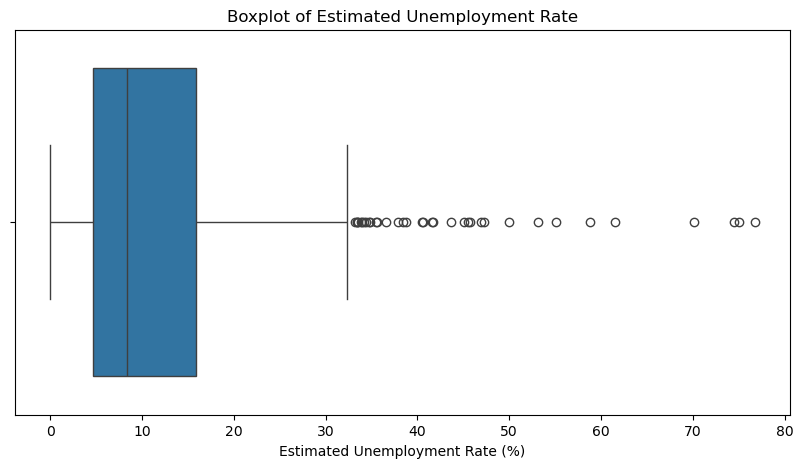

In [18]:
# Unemployment data may contain unusually high or low values.
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["Estimated Unemployment Rate (%)"]
)

plt.title("Boxplot of Estimated Unemployment Rate")
plt.show()

the above plot helps in indentifying extreme unemployment values

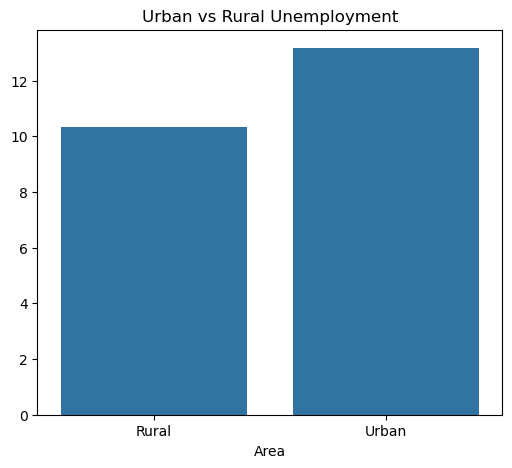

In [19]:
area_avg = (
    df.groupby("Area")["Estimated Unemployment Rate (%)"]
    .mean()
)

plt.figure(figsize=(6,5))

sns.barplot(
    x=area_avg.index,
    y=area_avg.values
)

plt.title("Urban vs Rural Unemployment")
plt.show()

Region-wise Average Unemployment Rate

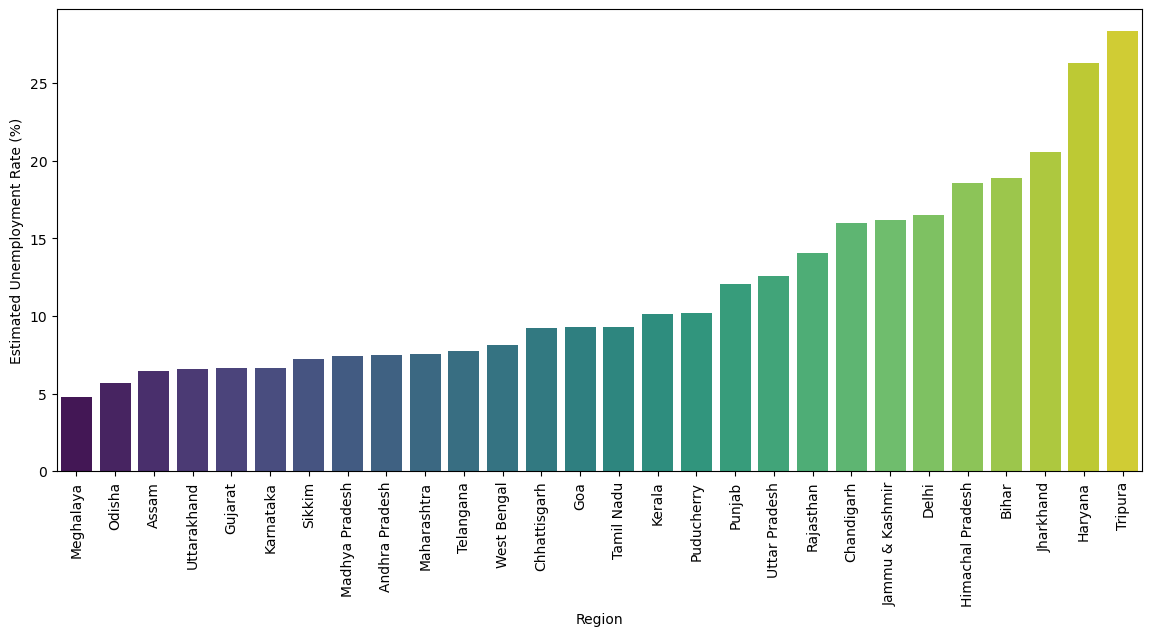

In [20]:
region_avg = (
    df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=True)
)

plt.figure(figsize=(14, 6))
plt.xticks(rotation=90)
sns.barplot(
    x=region_avg.index,
    y=region_avg.values,
    palette="viridis"
)
plt.ylabel("Estimated Unemployment Rate (%)")
plt.xlabel("Region")
plt.show()

## Observation

- The above chart compares the average unemployment rate across different regions.
- Some regions consistently experience higher unemployment than others.
- The visualization helps identify areas that may require greater employment support.

Month-wise Average Unemployment Trend

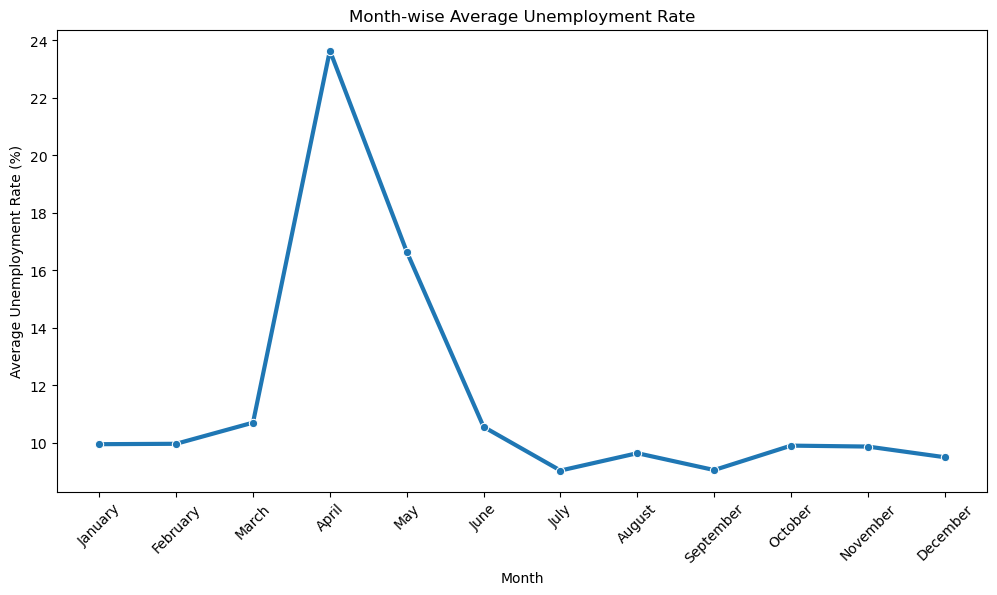

In [21]:
months = ['January','February','March','April','May','June','July','August','September','October','November','December']
month_avg = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"].mean().reindex(months)
)
plt.figure(figsize=(12,6))

sns.lineplot(
    x=month_avg.index,
    y=month_avg.values,
    marker="o",
    linewidth=3
)

plt.title("Month-wise Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)

plt.show()

## Observation

- This line chart illustrates the monthly trend in unemployment rates.
- Notice the months where unemployment rises or falls significantly.
- Such patterns may reflect seasonal employment changes and economic events like COVID-19.

Time-Series Analysis (3 Major States)

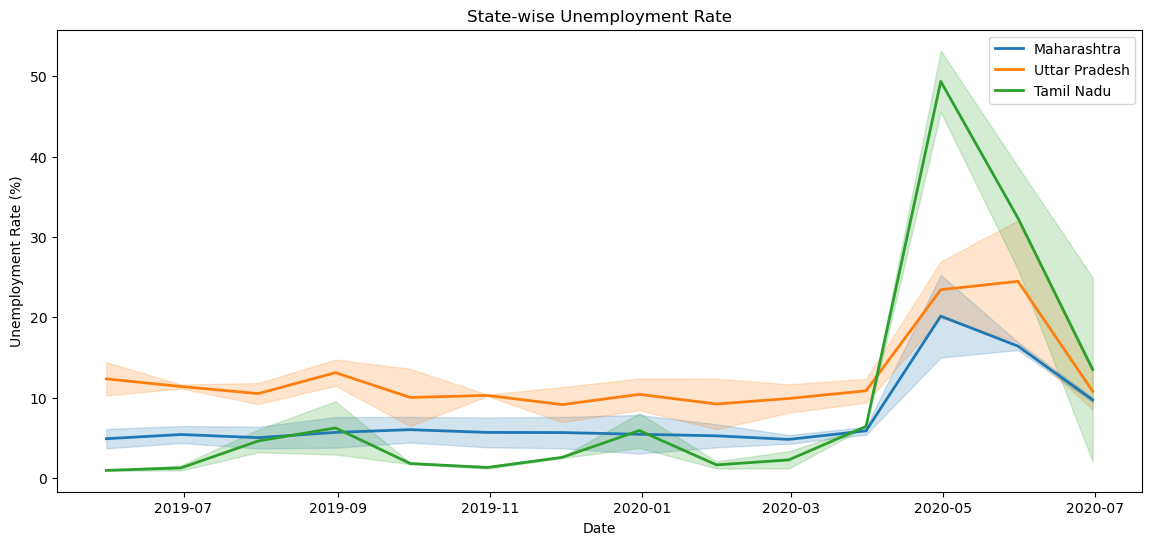

In [22]:
major_states = ["Maharashtra","Uttar Pradesh", "Tamil Nadu"]

plt.figure(figsize=(14,6))
for state in major_states:
    state_data = df[df["Region"] == state]
    sns.lineplot(
        x=state_data["Date"],
        y=state_data["Estimated Unemployment Rate (%)"],
        linewidth=2,
        label=state
    )
plt.title("State-wise Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.show()


## Observation

- The time-series graph compares unemployment trends across three major states.
- Different states experienced different levels of impact during the COVID-19 period.
- Sudden peaks indicate periods of increased unemployment.

Top 10 States with Highest Average Unemployment

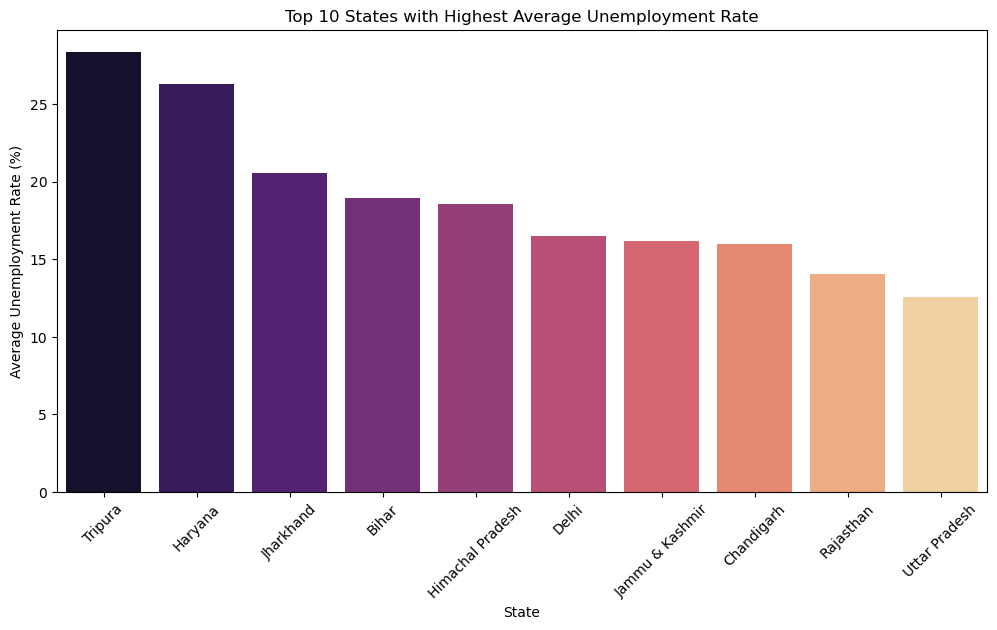

In [23]:
top_10_states = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False).head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_10_states.index,
    y=top_10_states.values,
    palette="magma"
)   
plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.xlabel("State")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Observation

- This chart highlights the top 10 regions with the highest average unemployment rates.
- These regions may require greater employment generation initiatives and policy attention.

Correlation Heatmap

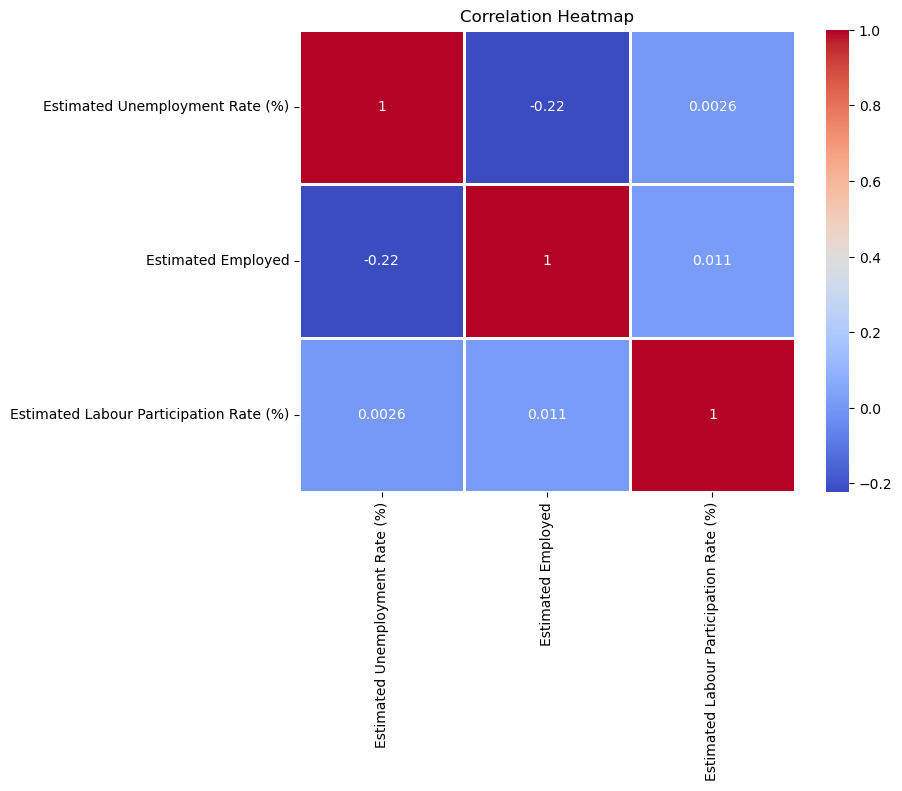

In [24]:
corr = df[ [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
    ""
] ].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=1,
)

plt.title("Correlation Heatmap")
plt.show()

## Observation

- The heatmap shows the correlation between unemployment rate, employment, and labour participation.
- Positive values indicate a direct relationship, while negative values indicate an inverse relationship.

Pre-COVID vs Post-COVID Analysis

In [25]:
#split datset into pre-Covid and post-covid periods
pre_covid = df[df["Date"] < "2020-03-01"]
post_covid = df[df["Date"] >= "2020-03-01"]

comparison = pd.DataFrame({
    "Period":["Pre-Covid","Post-Covid"],
    "Average Unemployment Rate (%)": [
        pre_covid["Estimated Unemployment Rate (%)"].mean(),
        post_covid["Estimated Unemployment Rate (%)"].mean()
    ]
})

comparison

,Period,Average Unemployment Rate (%)
0,Pre-Covid,9.509534
1,Post-Covid,17.774363


Visualize Pre-COVID vs Post-COVID

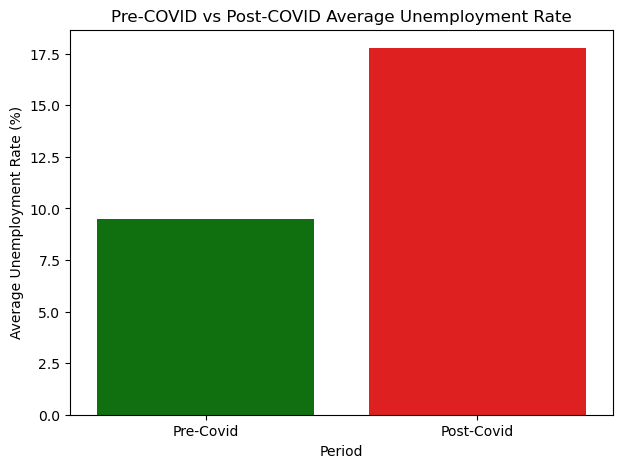

In [26]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=comparison,
    x="Period",
    y="Average Unemployment Rate (%)",
    palette=["green", "red"]
)

plt.title("Pre-COVID vs Post-COVID Average Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

## Observation

- The comparison clearly illustrates the impact of the COVID-19 pandemic on unemployment.
- The post-COVID period shows a noticeable increase in unemployment due to lockdowns, business closures, and economic disruptions.
- This demonstrates the significant effect of the pandemic on India's labour market.

In [29]:

print("KEY INSIGHTS")


print(f"\nHighest Average Unemployment Region : {region_avg.idxmax()}")
print(f"Average Rate : {region_avg.max():.2f}%")

print(f"\nLowest Average Unemployment Region : {region_avg.idxmin()}")
print(f"Average Rate : {region_avg.min():.2f}%")

print(f"\nOverall Average Unemployment Rate : {df['Estimated Unemployment Rate (%)'].mean():.2f}%")

print(f"\nAverage Pre-COVID Unemployment Rate : {comparison.iloc[0,1]:.2f}%")
print(f"Average Post-COVID Unemployment Rate : {comparison.iloc[1,1]:.2f}%")

KEY INSIGHTS

Highest Average Unemployment Region : Tripura
Average Rate : 28.35%

Lowest Average Unemployment Region : Meghalaya
Average Rate : 4.80%

Overall Average Unemployment Rate : 11.79%

Average Pre-COVID Unemployment Rate : 9.51%
Average Post-COVID Unemployment Rate : 17.77%


# Conclusion

This project analyzed unemployment trends in India using Python and data visualization techniques.

The dataset was cleaned and explored to understand unemployment patterns across different regions and time periods.

Key findings include:

- Significant variation in unemployment rates across different states and regions.
- Monthly trends revealed fluctuations that indicate seasonal and economic influences.
- Time-series analysis highlighted different unemployment patterns among major states.
- Correlation analysis provided insights into the relationship between unemployment, employment, and labour participation.
- The Pre-COVID vs Post-COVID comparison clearly demonstrated the adverse impact of the COVID-19 pandemic on unemployment in India.

Overall, this project provided practical experience in data preprocessing, exploratory data analysis (EDA), data visualization, and interpreting real-world socioeconomic data using Python.

## Recommendations

- High-unemployment states should receive targeted employment programs.
- Skill development initiatives should focus on regions with persistent unemployment.
- Government agencies should continuously monitor labour participation.
- Early identification of unemployment spikes can support timely policy decisions.